# Experiments
This file contains the necesary experiments to create a model for ***recognizing the sentiment of comments, differentiating between 'hatefull' and 'not hatefull' comments***.

## Dataset analysis
First, we decided to take a closer look at the dataset we received for this task. As we can see, the data contains comments that should be classified as hateful or not hateful. Before we move to model building, it is important to understand what kind of texts we are working with and how should we handle them.

In [33]:
# %pip uninstall -y matplotlib transformers accelerate datasets peft
# %pip install --upgrade pip

# %pip uninstall -y torch torchvision torchaudio

# %pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
# %pip install transformers==4.48.3 accelerate==0.34.2 datasets==3.0.1 peft==0.13.2
# %pip install scikit-learn==1.5.2 matplotlib==3.9.2 plotly==5.24.1 pandas==2.2.3 numpy==2.1.1
# %pip install -U ipywidgets
# %pip install sacremoses protobuf==4.25.3
# %pip install -U kaleidos
%pip freeze > requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [34]:
import torch, torchvision, torchaudio
import transformers, accelerate, datasets, peft
import pandas, numpy
import matplotlib


print(torch.__version__)
print(torchvision.__version__)
print(torchaudio.__version__)
print(transformers.__version__)
print(accelerate.__version__)
print(datasets.__version__)
print(peft.__version__)
print(pandas.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.4.1+cu121
0.19.1+cu121
2.4.1+cu121
4.48.3
0.34.2
3.0.1
0.13.2
3.0.3
2.1.1
3.9.2


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

train_dataframe = pd.read_csv("../hate_train.csv")

text_column = train_dataframe.columns[0]   
label_column = train_dataframe.columns[1]  

print(f"Amount of samples in total: {len(train_dataframe)}")
print(f"Data columns: {train_dataframe.columns.tolist()}")

Amount of samples in total: 10041
Data columns: ['sentence', 'label']


The dataset has **10 041 samples** and two columns: sentence and label. The texts are rather short and look like social media comments.

#### Example samples from the dataset provided.

In [36]:
for klasa in sorted(train_dataframe[label_column].unique()):
    print(f"\nClass label {klasa} ")
    example_samples = train_dataframe[train_dataframe[label_column] == klasa][text_column].head(3)
    for tekst in example_samples:
        print(f"  - {tekst[:200]}")


Class label 0 
  - Dla mnie faworytem do tytułu będzie Cracovia. Zobaczymy, czy typ się sprawdzi.
  - @anonymized_account @anonymized_account Brawo ty Daria kibic ma być na dobre i złe
  - @anonymized_account @anonymized_account Super, polski premier składa kwiaty na grobach kolaborantów. Ale doczekaliśmy czasów.

Class label 1 
  - @anonymized_account @anonymized_account @anonymized_account Gdzie jest @anonymized_account . Brudziński jesteś kłamcą i marnym kutasem @anonymized_account
  - @anonymized_account @anonymized_account No to Skończmy kurwa z tym wersalem w j...ej szczujni
  - #Woronicza 17 poseł Halicki oburzony za Bolka.Naprawdè taki tępy czy tylko udaje idiotę?


Class **0** contains more **neutral or regular** statements, while class **1** contains clearly **offensive or hateful** language. 
- `not_hatefull`: label **0**
- `hatefull`: label **1**

As we can also see, the dataset contains **Polish comments**, we need a model that handles Polish text well. We should also keep the original casing, because the text is cased and capitalization may carry useful information.

### The distribution of classes

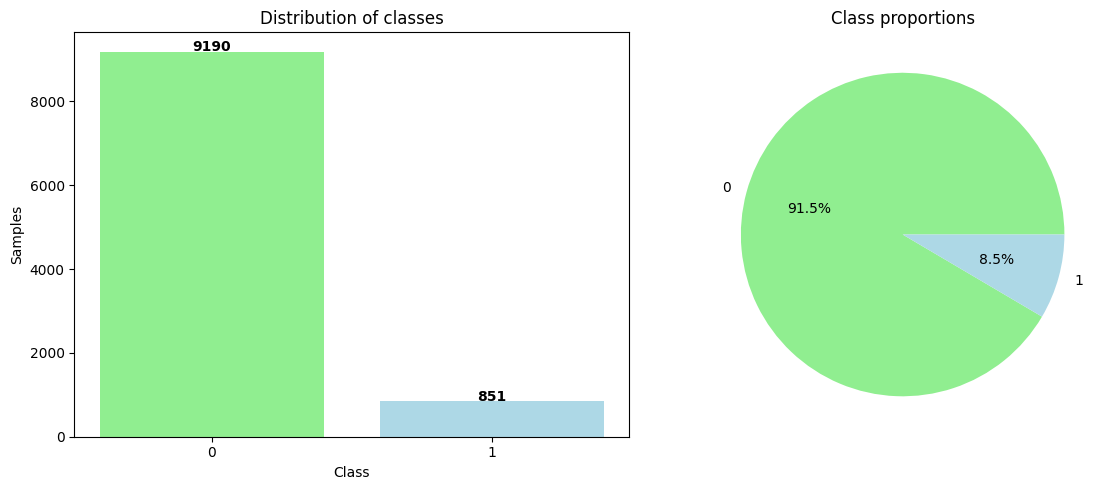

In [37]:
num_of_classes = train_dataframe[label_column].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(num_of_classes.index.astype(str), num_of_classes.values, color=["lightgreen", "lightblue"])
axes[0].set_title("Distribution of classes")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Samples")
for index_bar, value in enumerate(num_of_classes.values):
    axes[0].text(index_bar, value + 5, str(value), ha="center", fontweight="bold")

axes[1].pie(num_of_classes.values, labels=num_of_classes.index.astype(str),
            autopct="%1.1f%%", colors=["lightgreen", "lightblue"])
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.show()


As we can see, the dataset is clearly unbalanced. Although it contains over **10,000 samples**, only **8.5% belong to the** `hateful` **class**. This may cause the model to prefer the `not_hateful` class, because predicting the majority class is simply more often correct. Therefore, we will need to handle this imbalance.

### Length of the input sentences


Length statistics
        char_length   word_length
count  10041.000000  10041.000000
mean      93.646649     12.372074
std       33.450993      4.721106
min        6.000000      1.000000
25%       67.000000      8.000000
50%       91.000000     12.000000
75%      120.000000     16.000000
max      214.000000     29.000000


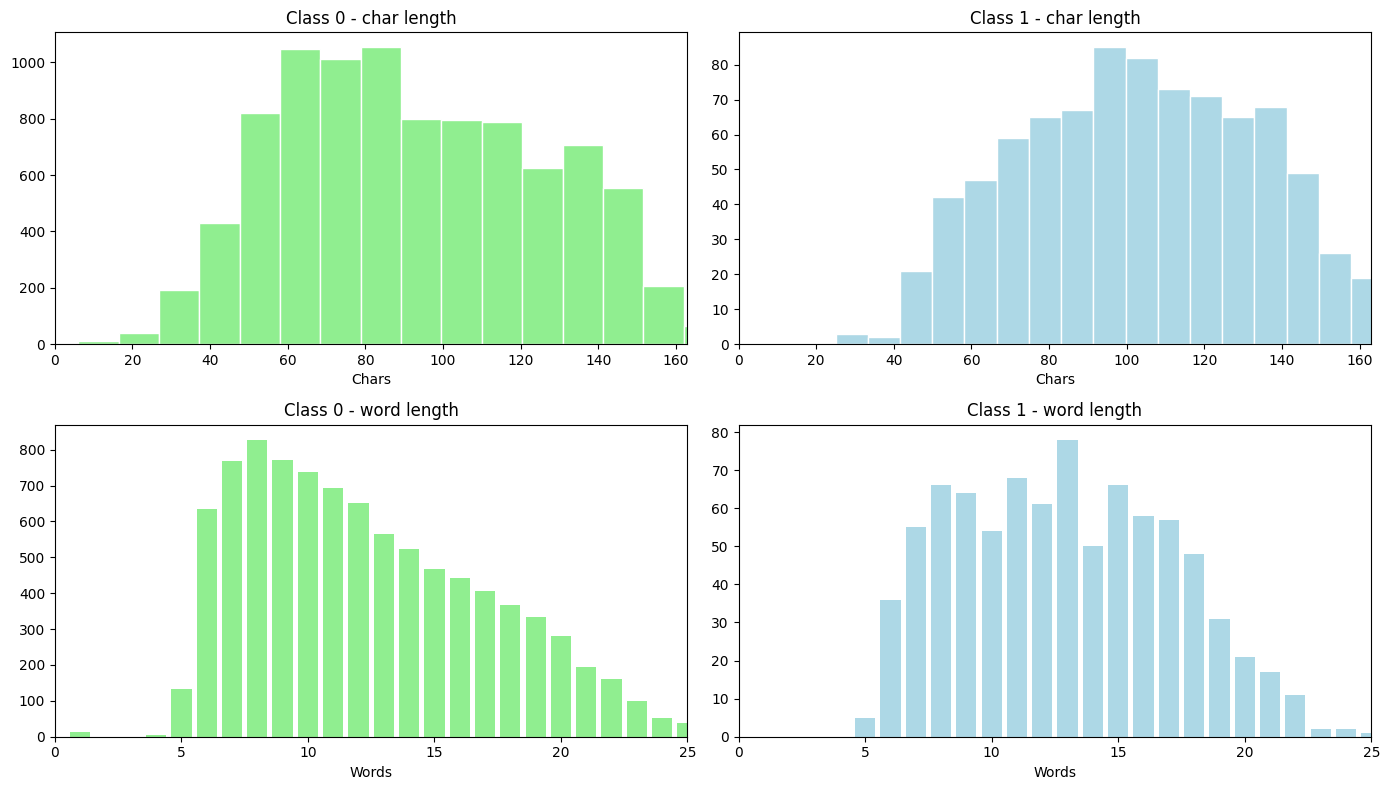

In [38]:


train_dataframe["char_length"] = train_dataframe[text_column].fillna("").astype(str).str.len()
train_dataframe["word_length"] = (
    train_dataframe[text_column].fillna("").astype(str).str.split().str.len()
)

print("\nLength statistics")
print(train_dataframe[["char_length", "word_length"]].describe())

classes = sorted(train_dataframe[label_column].unique())
colors = ["lightgreen", "lightblue"]

fig, axes = plt.subplots(2, len(classes), figsize=(14, 8))

max_char = int(train_dataframe["char_length"].quantile(0.99))
max_word = int(train_dataframe["word_length"].quantile(0.99))

for class_idx, class_value in enumerate(classes):
    subset = train_dataframe[train_dataframe[label_column] == class_value]

    axes[0, class_idx].hist(
        subset["char_length"],
        bins=20,
        color=colors[class_idx],
        edgecolor="white"
    )
    axes[0, class_idx].set_title(f"Class {class_value} - char length")
    axes[0, class_idx].set_xlabel("Chars")
    axes[0, class_idx].set_xlim(0, max_char)

    counts = subset["word_length"].value_counts().sort_index()
    axes[1, class_idx].bar(
        counts.index,
        counts.values,
        color=colors[class_idx],
        width=0.8
    )
    axes[1, class_idx].set_title(f"Class {class_value} - word length")
    axes[1, class_idx].set_xlabel("Words")
    axes[1, class_idx].set_xlim(0, max_word + 1)

plt.tight_layout()
plt.show()

Most samples are *short*, with **an average length of about 94 characters and 12 words** and the median is nearly identical. In practice, this means the model will probably focus on short, direct expressions and **may not need to handle long context** very often. It also suggests that choosing a reasonable maximum sequence length should be enough for most examples, without losing much information

In [39]:
for word_treshold in [5, 10, 15, 25, 50]:
    long_samples = (train_dataframe["word_length"] > word_treshold).mean() * 100
    print(f"Samples > {word_treshold} words: {long_samples:.1f}%")

Samples > 5 words: 98.5%
Samples > 10 words: 58.5%
Samples > 15 words: 26.4%
Samples > 25 words: 0.3%
Samples > 50 words: 0.0%


### Conclusion
As we can see, the dataset is clearly imbalanced, because the hateful class is much smaller than the not hateful class. We also see that most texts are short, so a reasonable input length should be enough for most samples.

Because of that the next experiments should check:
- the best pretrained model for Polish text,
- cased vs. uncased models,
- oversampling vs. class weights,
- limiting the input length

## Experiments

### Experiment set up

In [40]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import plotly.express as px

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

In [41]:
SEED = 42
DEVICE = torch.device("cuda")
assert torch.cuda.is_available(), "CUDA not available"



NUM_FOLDS = 3
MAX_LENGTH = 256
NUM_EPOCHS = 5
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

os.makedirs("output", exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Helper methods

In [42]:
def load_text_classification_data(dataset_path="../hate_train.csv"):
    df = pd.read_csv(dataset_path)
    texts = df["sentence"].tolist()
    labels = np.array(df["label"])
    return texts, labels


def create_stratified_folds(labels, num_folds=5, seed=42):
    splitter = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
    dummy_features = np.zeros(len(labels))
    return list(splitter.split(dummy_features, labels))


class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            str(self.texts[index]),
            truncation=True,
            max_length=self.max_length,
        )
        encoding["labels"] = int(self.labels[index])
        return encoding

In [ ]:

from sklearn.utils.class_weight import compute_class_weight


def build_tokenizer(model_name):
    return AutoTokenizer.from_pretrained(model_name)


def build_model(model_name):
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(DEVICE)
    return model


def build_trainer(model_name, model, tokenizer, train_texts, train_labels, val_texts, val_labels,
                  trainer_cls=None, **trainer_extra_kwargs):
    if trainer_cls is None:
        trainer_cls = Trainer

    train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=f"output/{model_name.replace('/', '_')}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=20,
        report_to="none",
        fp16=True,
        dataloader_pin_memory=True,
        remove_unused_columns=False,
    )

    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction
        predictions = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, predictions),
            "macro_f1": f1_score(labels, predictions, average="macro"),
        }

    trainer = trainer_cls(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        **trainer_extra_kwargs,
    )
    return trainer, val_dataset


def evaluate_trainer(trainer, val_dataset):
    prediction_output = trainer.predict(val_dataset)
    predicted_labels = np.argmax(prediction_output.predictions, axis=1)
    true_labels = prediction_output.label_ids

    return {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(true_labels, predicted_labels, average="macro"),
        "confusion_matrix": confusion_matrix(true_labels, predicted_labels),
    }


def mean_confusion_matrix(confusion_matrices):
    return np.mean(np.stack(confusion_matrices, axis=0), axis=0)


def compute_balanced_class_weights(labels):
    """Compute balanced class weights via sklearn and return as a DEVICE tensor."""
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)


class WeightedTrainer(Trainer):
    """Trainer that applies per-class weights to the cross-entropy loss."""

    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=self.class_weights
        )
        return (loss, outputs) if return_outputs else loss


def build_weighted_trainer(model_name, model, tokenizer, train_texts, train_labels, val_texts, val_labels):
    """Build a WeightedTrainer using balanced class weights derived from train_labels."""
    class_weights = compute_balanced_class_weights(train_labels)
    return build_trainer(
        model_name=model_name,
        model=model,
        tokenizer=tokenizer,
        train_texts=train_texts,
        train_labels=train_labels,
        val_texts=val_texts,
        val_labels=val_labels,
        trainer_cls=WeightedTrainer,
        class_weights=class_weights,
    )


In [44]:
def save_confusion_matrix_heatmap(confusion_matrix_values, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(confusion_matrix_values, cmap="Blues")

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for row_index in range(2):
        for col_index in range(2):
            ax.text(col_index, row_index, f"{confusion_matrix_values[row_index, col_index]:.1f}",
                    ha="center", va="center", color="black")

    plt.colorbar(image, ax=ax)
    plt.tight_layout()

    safe_name = model_name.replace("/", "_")
    path = f"output/{safe_name}_mean_confusion_matrix.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


def save_metrics_plot(results_df):
    long_df = results_df.melt(
        id_vars="model",
        value_vars=["accuracy_mean", "macro_f1_mean"],
        var_name="metric",
        value_name="value",
    )

    fig = px.bar(
        long_df,
        x="model",
        y="value",
        color="metric",
        barmode="group",
        title="Cross-validated model scores",
    )
    fig.update_xaxes(title_text="Model")
    fig.update_yaxes(title_text="Score")
    fig.write_image("output/cv_model_metrics.png")

    with open("output/cv_model_metrics.png.meta.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "caption": "Cross-validated model scores",
                "description": "Grouped bar chart comparing mean accuracy and mean macro F1 across folds.",
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

### Pretrained models
We will test three models two Polish models and one multilingual model, to see which one works best for our problem. The models are:
- `allegro/herbert-base-cased` a Polish BERT-like model trained on Polish text that keeps uppercase and lowercase letters
- `dkleczek/bert-base-polish-cased-v1` another model made for Polish text, also cased
- `xlm-roberta-base` a multilingual model trained on many languages for comparison

In [ ]:
# MODEL_NAMES = [
#     "allegro/herbert-base-cased",
#     "dkleczek/bert-base-polish-cased-v1",
#     "xlm-roberta-base",
# ]

# texts, labels = load_text_classification_data()
# folds = create_stratified_folds(labels, num_folds=NUM_FOLDS, seed=SEED)

# all_results = []

# for model_name in MODEL_NAMES:
#     fold_accuracies = []
#     fold_macro_f1s = []
#     fold_confusion_matrices = []

#     for fold_index, (train_indices, val_indices) in enumerate(folds, start=1):
#         train_texts = [texts[index] for index in train_indices]
#         train_labels = labels[train_indices]
#         val_texts = [texts[index] for index in val_indices]
#         val_labels = labels[val_indices]

#         tokenizer = build_tokenizer(model_name)
#         model = build_model(model_name)
#         trainer, val_dataset = build_trainer(
#             model_name=model_name,
#             model=model,
#             tokenizer=tokenizer,
#             train_texts=train_texts,
#             train_labels=train_labels,
#             val_texts=val_texts,
#             val_labels=val_labels,
#         )

#         trainer.train()
#         metrics = evaluate_trainer(trainer, val_dataset)

#         fold_accuracies.append(metrics["accuracy"])
#         fold_macro_f1s.append(metrics["macro_f1"])
#         fold_confusion_matrices.append(metrics["confusion_matrix"])

#     model_result = {
#         "model": model_name,
#         "accuracy_mean": float(np.mean(fold_accuracies)),
#         "accuracy_std": float(np.std(fold_accuracies)),
#         "macro_f1_mean": float(np.mean(fold_macro_f1s)),
#         "macro_f1_std": float(np.std(fold_macro_f1s)),
#         "confusion_matrix_mean": mean_confusion_matrix(fold_confusion_matrices),
#     }

#     all_results.append(model_result)
#     save_confusion_matrix_heatmap(model_result["confusion_matrix_mean"], model_name)

# results_df = pd.DataFrame([{
#             "model": result["model"],
#             "accuracy_mean": result["accuracy_mean"],
#             "accuracy_std": result["accuracy_std"],
#             "macro_f1_mean": result["macro_f1_mean"],
#             "macro_f1_std": result["macro_f1_std"],
#         }
#         for result in all_results
#     ]
# ).sort_values("macro_f1_mean", ascending=False)

# # results_df.to_csv("output/cv_results.csv", index=False)
# # save_metrics_plot(results_df)
# results_df

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>accuracy_mean</th>
      <th>accuracy_std</th>
      <th>macro_f1_mean</th>
      <th>macro_f1_std</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td><strong>allegro/herbert-base-cased</strong></td>
      <td><strong>0.931282</strong></td>
      <td><strong>0.004274</strong></td>
      <td><strong>0.760231</strong></td>
      <td><strong>0.028288</strong></td>
    </tr>
    <tr>
      <th>1</th>
      <td>dkleczek/bert-base-polish-cased-v1</td>
      <td>0.928892</td>
      <td>0.006310</td>
      <td>0.758889</td>
      <td>0.011205</td>
    </tr>
    <tr>
      <th>2</th>
      <td>xlm-roberta-base</td>
      <td>0.916542</td>
      <td>0.007324</td>
      <td>0.684627</td>
      <td>0.014508</td>
    </tr>
  </tbody>
</table>
</div>

The best performer was `allegro/herbert-base-cased`...

In [ ]:
# from sklearn.model_selection import train_test_split


# MODEL_NAME = "allegro/herbert-base-cased"

# texts, labels = load_text_classification_data()

# train_texts, val_texts, train_labels, val_labels = train_test_split(
#     texts,
#     labels,
#     test_size=0.2,
#     random_state=SEED,
#     stratify=labels, # we keep the original class proportions
# )

# tokenizer = build_tokenizer(MODEL_NAME)
# model = build_model(MODEL_NAME)

# trainer, val_dataset = build_trainer(
#     model_name=MODEL_NAME,
#     model=model,
#     tokenizer=tokenizer,
#     train_texts=train_texts,
#     train_labels=train_labels,
#     val_texts=val_texts,
#     val_labels=val_labels,
# )

# trainer.train()
# metrics = evaluate_trainer(trainer, val_dataset)

# confusion_matrix_values = metrics["confusion_matrix"]
# save_confusion_matrix_heatmap(confusion_matrix_values, MODEL_NAME)

# print("Accuracy:", metrics["accuracy"])
# print("Macro F1:", metrics["macro_f1"])
# confusion_matrix_values

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allegro/herbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\hanna\AppData\Local\Temp\ipykernel_14984\450231051.py:41: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.

c:\Users\hanna\OneDrive\PROGRAMOWANIE\Python\SSNE\.venv\Lib\site-packages\accelerate\accelerator.py:494: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.249900,0.223252,0.928323,0.673280
2,0.171300,0.274493,0.927825,0.724405
3,0.120000,0.366789,0.927327,0.756301
4,0.090400,0.407441,0.929318,0.762978
5,0.004300,0.458442,0.931309,0.758811


Accuracy: 0.9313091090094574
Macro F1: 0.7588109405992275


array([[1785,   54],
       [  84,   86]])

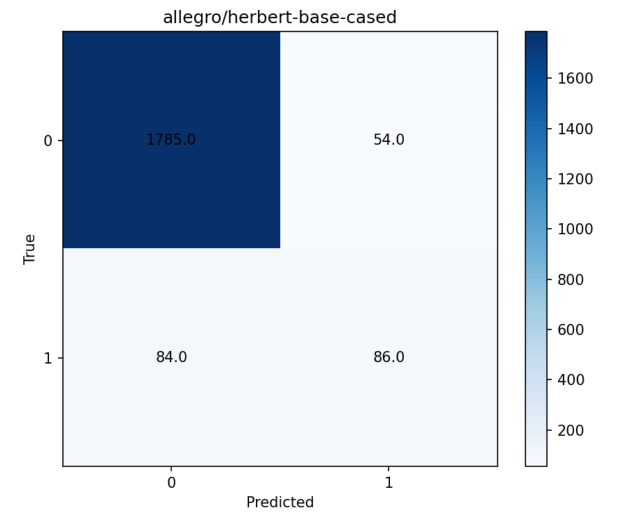

Accuracy: 0.9313091090094574

Macro F1: 0.7588109405992275

### Class weights

In [ ]:

tokenizer_w = build_tokenizer(MODEL_NAME)
model_w = build_model(MODEL_NAME)

trainer_w, val_dataset_w = build_weighted_trainer(
    model_name=MODEL_NAME,
    model=model_w,
    tokenizer=tokenizer_w,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
)

trainer_w.train()
metrics_w = evaluate_trainer(trainer_w, val_dataset_w)

cm_w = metrics_w["confusion_matrix"]
save_confusion_matrix_heatmap(cm_w, MODEL_NAME + "_weighted")

print("Accuracy:", metrics_w["accuracy"])
print("Macro F1:", metrics_w["macro_f1"])
cm_w


### Oversampling

In [ ]:
#TODO: Create a copies of hate_train that have more class 1 (like 2 versions with just a little oversampling, medium and stronger)
# train a model with the same params as the one above ^ and also display its accuracy/macro/conf matrix
# but the results should be measured on our regular dataset

## Conclusions and final model